# 4.1 ML Foundations

- Types of ML
- Supervised vs Unsupervised
- Bias-Variance tradeoff
- Overfitting & Underfitting
- Cross Validation
> **Source:** [Introduction to Machine Learning](https://www.geeksforgeeks.org/machine-learning/introduction-machine-learning/)

---



## What is Machine Learning?

**Machine Learning** is a technique that allows computers to **learn from data and make decisions without explicit programming**.

The approach works by:
1. Identifying patterns in data
2. Using those patterns for predictions

**Applications:** Image recognition, speech processing, recommendation systems

### How Machines Learn (6 Steps)
1. **Data Input** — Feed raw data
2. **Apply Algorithm** — Choose learning approach
3. **Model Training** — Learn from data
4. **Feedback Loop** — Compare predictions vs actual
5. **Iterative Experience** — Improve over iterations
6. **Evaluation** — Test on new unseen data

---
## 1. Types of Machine Learning

### 1.1 Supervised Learning
- Trains models using **labeled data** where inputs have known correct outputs
- Model compares predictions against actual answers and improves iteratively
- Used for **classification** and **regression** problems

**Algorithms:** Linear Regression, Polynomial Regression, Ridge, Decision Trees, Random Forests, SVM, Naive Bayes

**Applications:** Image classification, medical diagnosis, fraud detection, NLP

---

### 1.2 Unsupervised Learning
- Works with **unlabeled data** to discover hidden patterns independently
- No predefined outputs; model finds structure on its own
- Useful when labeling data is impractical or difficult

**Algorithms:** K-Means, Hierarchical Clustering, DBSCAN, Apriori, FP-Growth

**Applications:** Anomaly detection, recommendation systems, customer segmentation, scientific discovery

---

### 1.3 Reinforcement Learning
- An **agent** learns through **trial-and-error** interaction with an environment
- Receives **rewards** for correct actions, **penalties** for mistakes

**Applications:** Robotics, gaming (AlphaGo), autonomous systems

---
## 2. Supervised vs Unsupervised Learning

| Aspect | Supervised | Unsupervised |
|--------|-----------|-------------- |
| **Data Type** | Labeled | Unlabeled |
| **Accuracy** | Highly accurate | Less accurate |
| **Complexity** | Simpler method | Computationally complex |
| **Classes Known** | Yes | No |
| **Supervision** | Requires guidance | No supervision needed |

### Supervised — Sub-types
| Type | Output | Example Algorithms |
|------|--------|-------------------|
| **Regression** | Continuous values | Linear, Polynomial, Ridge |
| **Classification** | Categorical values | Decision Trees, SVM, Naive Bayes |

### Unsupervised — Sub-types
| Type | Goal | Example Algorithms |
|------|------|-------------------|
| **Clustering** | Group similar data points | K-Means, Hierarchical, DBSCAN |
| **Association** | Find item relationships | Apriori, Eclat, FP-Growth |

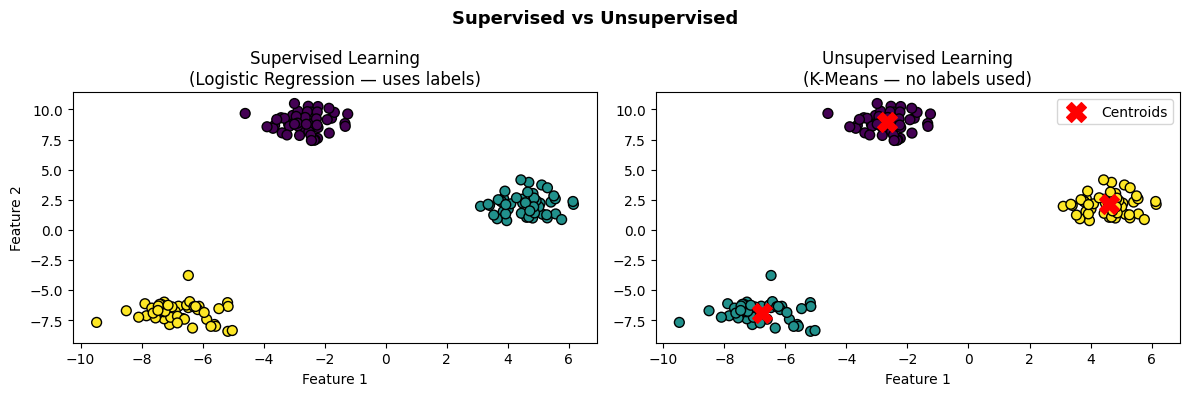

Supervised  accuracy: 100.00%
Unsupervised inertia: 181.50  (lower = tighter clusters)


In [1]:
# ============================================================
# EXAMPLE: Supervised vs Unsupervised on the same dataset
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

# Generate labeled data (for supervised)
X, y = make_blobs(n_samples=150, centers=3, cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Supervised: Logistic Regression (uses labels y) ---
clf = LogisticRegression(max_iter=200)
clf.fit(X, y)
axes[0].scatter(X[:, 0], X[:, 1], c=clf.predict(X), cmap='viridis', edgecolors='k', s=50)
axes[0].set_title('Supervised Learning\n(Logistic Regression — uses labels)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# --- Unsupervised: K-Means (ignores labels y) ---
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
km.fit(X)  # No y passed!
axes[1].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', edgecolors='k', s=50)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c='red', marker='X', s=200, label='Centroids')
axes[1].set_title('Unsupervised Learning\n(K-Means — no labels used)')
axes[1].set_xlabel('Feature 1')
axes[1].legend()

plt.suptitle('Supervised vs Unsupervised', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Supervised  accuracy: {clf.score(X, y):.2%}')
print(f'Unsupervised inertia: {km.inertia_:.2f}  (lower = tighter clusters)')

### Code Walkthrough — Supervised vs Unsupervised

**Goal:** Run both types of learning on the **exact same dataset** side-by-side so you can see the difference.

| Step | What happens |
|------|--------------|
| `make_blobs(...)` | Creates 150 artificial data points arranged in 3 well-separated clusters. Each point has 2 features (x, y coordinates). Labels `y` are also generated (0, 1, 2). |
| `LogisticRegression` | **Supervised** — `clf.fit(X, y)` passes both the data AND the labels. The model learns the boundary between the 3 classes using those labels. |
| `KMeans` | **Unsupervised** — `km.fit(X)` passes only the data, no labels. K-Means finds 3 groups purely by measuring distances between points. |
| `clf.score(X, y)` | Returns accuracy: how many points the supervised model classified correctly. |
| `km.inertia_` | Sum of squared distances from each point to its nearest cluster center. Lower = tighter/better clusters. |

**What to observe in the plot:**
- Left plot: colors are assigned by the *learned classifier* (used labels during training)
- Right plot: colors are assigned by *distance to centroids* (no labels used at all)
- Red `X` markers on right = centroids (center of each K-Means cluster)

---
## 3. Bias-Variance Tradeoff

> **Source:** [Bias-Variance Trade-Off](https://www.geeksforgeeks.org/ml-bias-variance-trade-off/)



$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

---

### Definitions

| Term | Definition |
|------|------------|
| **Bias** | *"Error caused by overly simple assumptions in the model, which may lead to underfitting."* It represents *"error caused by incorrect assumptions in the model."* |
| **Variance** | *"Error caused by the model being too sensitive to training data, which may lead to overfitting."* It reflects *"error caused by sensitivity to training data."* |
| **Irreducible Error** | *"Random noise in the data that cannot be eliminated."* |

---

### The Tradeoff

| Model Complexity | Bias | Variance | Result |
|-----------------|------|----------|--------|
| Too Simple | High ↑ | Low ↓ | **Underfitting** |
| Just Right | Low ↓ | Low ↓ | **Good Generalization** ✓ |
| Too Complex | Low ↓ | High ↑ | **Overfitting** |

> **Goal:** Find the *"balanced middle ground where both bias and variance are reasonably low"* so the model *"captures patterns while still generalizing well to new data."*

```
Error
  |
  |  \         /
  |   \  opt  /  ← Variance
  |    \/    /
  |    /\   /
  |   /  \_/  ← Total Error
  |  /   Bias²
  |_________________________
          Model Complexity →
```

### Bias and Variance — In Simple Words

**Bias** — Our model will not be trained well with the training data. There will be high training error when we train our model with the data.

**Variance** — If you train your data on training data and obtain a very low error, upon changing the data and then training the same previous model you experience high error, this is variance.

**Noise** - If data contains any outliers then it does not perform well on training data.

- The linear regression is of different types
    - The Simple linear regression
    - The polynomial linear regression
    - The Multinomial linear regression and etc


### Polynomial Degree & Bias-Variance

| | **degree = 1** | **degree = 2** | **degree = 4** |
|---|---|---|---|
| **Formula** | $\theta_0 + \theta_1 x$ | $\theta_0 + \theta_1 x + \theta_2 x^2$ | $\theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \theta_4 x^4$ |
| **Training Error** | High | Low | Low |
| **Bias** | High | Low | Low |
| **Variance** | Low | Low | High |
| **Test Error** | High | Low | High |
| **Problem** | Underfitting | Good Fit ✓ | Overfitting |

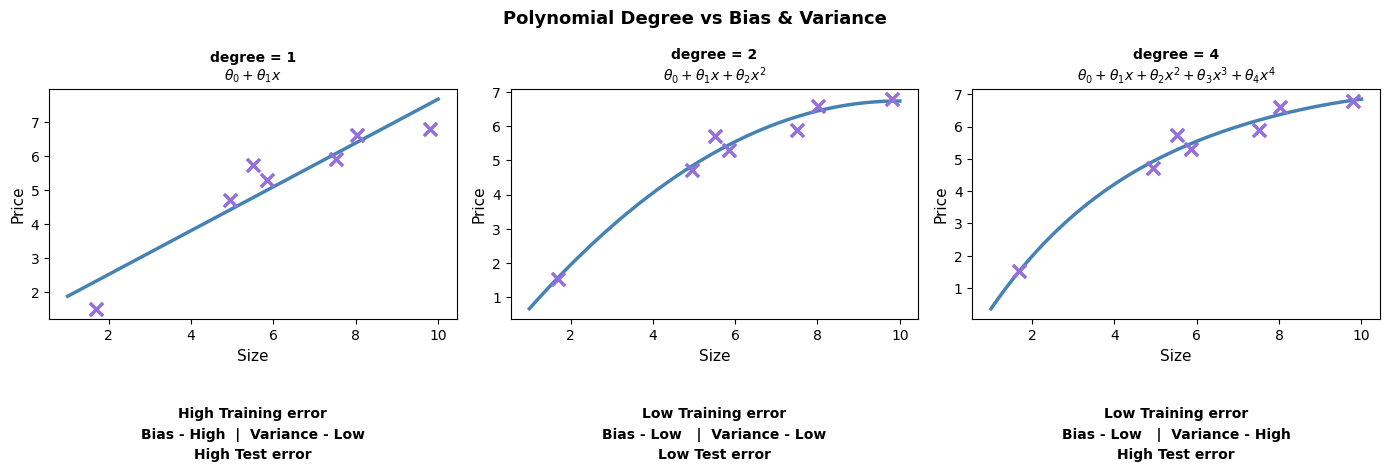

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(7)

size  = np.sort(np.random.uniform(1, 10, 7))
price = np.log(size) * 3 + np.random.normal(0, 0.3, 7)
X      = size.reshape(-1, 1)
X_plot = np.linspace(1, 10, 200).reshape(-1, 1)

configs = [
    (1, "degree = 1",
     r"$\theta_0 + \theta_1 x$",
     "High Training error\nBias - High  |  Variance - Low\nHigh Test error"),
    (2, "degree = 2",
     r"$\theta_0 + \theta_1 x + \theta_2 x^2$",
     "Low Training error\nBias - Low   |  Variance - Low\nLow Test error"),
    (4, "degree = 4",
     r"$\theta_0+\theta_1 x+\theta_2 x^2+\theta_3 x^3+\theta_4 x^4$",
     "Low Training error\nBias - Low   |  Variance - High\nHigh Test error"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.subplots_adjust(bottom=0.3)

for ax, (deg, title, formula, labels) in zip(axes, configs):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X, price)
    ax.scatter(size, price, color='mediumpurple', marker='x', s=90, linewidths=2.5, zorder=5)
    ax.plot(X_plot, model.predict(X_plot), color='steelblue', lw=2.5)
    ax.set_xlabel('Size', fontsize=11)
    ax.set_ylabel('Price', fontsize=11)
    ax.set_title(title + '\n' + formula, fontsize=10, fontweight='bold', pad=6)
    ax.text(0.5, -0.38, labels, transform=ax.transAxes,
            ha='center', va='top', fontsize=10, fontweight='bold', linespacing=1.6)

plt.suptitle('Polynomial Degree vs Bias & Variance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


1. underfitting
2. Generalized fitting
3. Overfitting

- A supervised machine learning model aims to train itself on the input variable (X) , so in such a way that the predicted values (Y) are close to actual values as possiblr.
- The difference between actual and predicted values is the error and it is used to evaluate the model.
- The error comprises of 
    - Bias error
    - Variance error
    - Noise error

---
## Quick Summary

| Concept | Key Formula / Rule |
|---------|-------------------|
| **Total Error** | $\text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$ |
| **Underfitting** | High Bias + Low Variance → Poor train & test |
| **Overfitting** | Low Bias + High Variance → Great train, poor test |
| **K-Fold CV Score** | $\frac{1}{k} \sum_{i=1}^{k} \text{Score}_i$ |
| **Supervised** | Labeled data → Classification / Regression |
| **Unsupervised** | Unlabeled data → Clustering / Association |

---

### Preventing Overfitting
- Use **regularization** (L1/L2)
- Reduce model complexity
- Use **cross validation** to evaluate
- Collect more training data
- Use **dropout** (neural networks)

### Preventing Underfitting
- Increase model complexity
- Reduce regularization
- Add more/better features
- Train longer

---
*Sources: [GeeksforGeeks ML Introduction](https://www.geeksforgeeks.org/machine-learning/introduction-machine-learning/) | [Bias-Variance Tradeoff](https://www.geeksforgeeks.org/ml-bias-variance-trade-off/) | [Overfitting & Underfitting](https://www.geeksforgeeks.org/underfitting-and-overfitting-in-machine-learning/) | [Cross Validation](https://www.geeksforgeeks.org/cross-validation-machine-learning/)*

In [5]:
# Simple Bias vs Variance Example
# True pattern: y = x^2   (a curve, not a line)

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = X.ravel()**2 + np.random.normal(0, 0.5, 50)  

print('x',X) # true pattern + noise
print('y',y) # true pattern + noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
# HIGH BIAS model  → degree=1 (straight line, can't fit a curve)
model_bias = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_bias.fit(X_train, y_train)

# HIGH VARIANCE model → degree=15 (too complex, memorizes noise)
model_var = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_var.fit(X_train, y_train)

print("=== High BIAS (degree=1 — straight line) ===")
print(f"  Train Error : {mean_squared_error(y_train, model_bias.predict(X_train)):.2f}")
print(f"  Test  Error : {mean_squared_error(y_test,  model_bias.predict(X_test)):.2f}")
print("  → Both errors HIGH = model too simple\n")

print("=== High VARIANCE (degree=15 — wiggly) ===")
print(f"  Train Error : {mean_squared_error(y_train, model_var.predict(X_train)):.2f}")
print(f"  Test  Error : {mean_squared_error(y_test,  model_var.predict(X_test)):.2f}")
print("  → Train error LOW, Test error HIGH = model memorized training data")

x [[-3.        ]
 [-2.87755102]
 [-2.75510204]
 [-2.63265306]
 [-2.51020408]
 [-2.3877551 ]
 [-2.26530612]
 [-2.14285714]
 [-2.02040816]
 [-1.89795918]
 [-1.7755102 ]
 [-1.65306122]
 [-1.53061224]
 [-1.40816327]
 [-1.28571429]
 [-1.16326531]
 [-1.04081633]
 [-0.91836735]
 [-0.79591837]
 [-0.67346939]
 [-0.55102041]
 [-0.42857143]
 [-0.30612245]
 [-0.18367347]
 [-0.06122449]
 [ 0.06122449]
 [ 0.18367347]
 [ 0.30612245]
 [ 0.42857143]
 [ 0.55102041]
 [ 0.67346939]
 [ 0.79591837]
 [ 0.91836735]
 [ 1.04081633]
 [ 1.16326531]
 [ 1.28571429]
 [ 1.40816327]
 [ 1.53061224]
 [ 1.65306122]
 [ 1.7755102 ]
 [ 1.89795918]
 [ 2.02040816]
 [ 2.14285714]
 [ 2.26530612]
 [ 2.3877551 ]
 [ 2.51020408]
 [ 2.63265306]
 [ 2.75510204]
 [ 2.87755102]
 [ 3.        ]]
y [ 9.24835708  8.21116772  7.91443152  7.69237707  6.18404784  5.58430595
  5.92121824  4.9755541   3.84731195  3.87352908  2.92072764  2.49974654
  2.46375498  1.02628366  0.79060231  1.07204241  0.57688307  1.00052225
  0.17947401 -0.25259083  

Same data, 3 models. Watch Train Error vs Test Error tell the whole story.

| Model | Train Error | Test Error | Meaning |
|-------|-------------|------------|---------|
| degree=1 | High | High | **High Bias** — too simple, misses pattern |
| degree=3 | Low | Low | **Balanced** — just right ✓ |
| degree=15 | ~0 | High | **High Variance** — memorized training noise |

In [9]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(0)

# Simple dataset: y = x^2 + noise
X = np.linspace(-3, 3, 40).reshape(-1, 1)
y = X.ravel()**2 + np.random.normal(0, 1, 40)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"{'Model':<15} {'Train MSE':>12} {'Test MSE':>12}  Verdict")
print("-" * 55)

for degree, label in [(1, 'High Bias'), (3, 'Balanced'), (15, 'High Variance')]:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree)),
        ('lr',   LinearRegression())
    ])
    model.fit(X_train, y_train)
    train_err = mean_squared_error(y_train, model.predict(X_train))
    test_err  = mean_squared_error(y_test,  model.predict(X_test))
    print(f"degree={degree:<8} {train_err:>12.2f} {test_err:>12.2f}  ← {label}")

Model              Train MSE     Test MSE  Verdict
-------------------------------------------------------
degree=1               10.34        10.48  ← High Bias
degree=3                0.85         1.41  ← Balanced
degree=15               0.42         1.44  ← High Variance


Bias — the model is too simple and makes wrong assumptions.

It misses the real pattern. Error is the same whether on training or test data. Like a student who studied the wrong topic.

Variance — the model is too sensitive to the training data.

It memorizes the training data including noise, so it fails on new data. Like a student who memorized answers word-for-word but can't handle a slightly different question.



In [ ]:
# High Bias        High Variance      High Bias         Low Bias
# Low Variance     Low Bias           High Variance     Low Variance
                                    
#   x x              .   x              x   .             . x .
#   x x            x   .             .   x  .            . x x .
#                    x .               x   .               . x .
  
# Consistently     Scattered but      Scattered AND      Consistently
# wrong spot       near center        wrong spot         near center ✓
# (underfitting)   (overfitting)      (worst case)       (ideal)


---
## 4. Overfitting & Underfitting

> **Source:** [Underfitting and Overfitting](https://www.geeksforgeeks.org/underfitting-and-overfitting-in-machine-learning/)

### 4.1 Underfitting

**Definition:** A model that *"is too simple and does not cover all real patterns in the data,"* performing poorly on **both training and test** datasets. High bias and high variance

- **Primary Cause:** High bias, Low variance
- The model learns an *overly simplified representation* of the data

**Contributing Factors:**
- Overly simplistic model architecture
- Excessive regularization
- Insufficient or weak features
- Inadequate training duration
- Strong model assumptions that ignore actual patterns

---

### 4.2 Overfitting

**Definition:** The model *"learns not just the underlying pattern, but also noise or random quirks in the training data,"* excelling on training data while **failing on test data**. Low bias and high variance.

- **Primary Cause:** High variance, Low bias
- The model essentially *memorizes training data* rather than generalizing patterns

**Contributing Factors:**
- Excessive model complexity
- Too many features relative to data size
- Insufficient training samples
- Missing regularization techniques
- Model reacts too strongly to training data variations

---

### 4.3 Ideal Balance

> A quality model achieves *"the right spot"* by being *"complex enough to capture real patterns, but not so complex that it memorizes noise."*

| Condition | Train Error | Test Error | Cause |
|-----------|-------------|------------|-------|
| **Underfitting** | High | High | Model too simple |
| **Good Fit** | Low | Low | Just right ✓ |
| **Overfitting** | Very Low | High | Model too complex |

- Train error is less and Test error is more -- Overfitting

In [6]:
# Simple Overfitting & Underfitting Example
# True pattern: y = x^2

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)
X = np.linspace(-3, 3, 40).reshape(-1, 1)
y = X.ravel()**2 + np.random.normal(0, 0.5, 40)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Underfitting (degree=1)" : make_pipeline(PolynomialFeatures(1),  LinearRegression()),
    "Good Fit    (degree=2)" : make_pipeline(PolynomialFeatures(2),  LinearRegression()),
    "Overfitting (degree=15)": make_pipeline(PolynomialFeatures(15), LinearRegression()),
}

print(f"{'Model':<28} {'Train MSE':>10} {'Test MSE':>10}  Result")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train, y_train)
    tr = mean_squared_error(y_train, model.predict(X_train))
    te = mean_squared_error(y_test,  model.predict(X_test))

    if tr > 2 and te > 2:
        result = "Both high   → Underfitting"
    elif tr < 1 and te < 1:
        result = "Both low    → Good Fit ✓"
    else:
        result = "Train low, Test high → Overfitting"

    print(f"{name:<28} {tr:>10.2f} {te:>10.2f}  {result}")

Model                         Train MSE   Test MSE  Result
-----------------------------------------------------------------
Underfitting (degree=1)            8.26      10.00  Both high   → Underfitting
Good Fit    (degree=2)             0.20       0.20  Both low    → Good Fit ✓
Overfitting (degree=15)            0.10      13.19  Train low, Test high → Overfitting


### Code Explanation — Overfitting & Underfitting

**Dataset:** `y = x² + noise` — the true pattern is a curve (parabola). We have 40 points, split 70% train / 30% test.

**What each model does:**

| Model | What it tries to fit | Problem |
|-------|----------------------|---------|
| `degree=1` | A straight line through curved data | Can never capture the curve → always wrong |
| `degree=2` | A parabola — exactly matches the true pattern | Just right ✓ |
| `degree=15` | An extremely wiggly curve | Passes through every train point but falls apart on new data |

**How to read the output:**

- **Train MSE** — error on data the model was trained on
- **Test MSE** — error on new data the model has never seen

| Pattern | Meaning |
|---------|---------|
| Train HIGH + Test HIGH | **Underfitting** — model didn't even learn the training data |
| Train LOW + Test LOW | **Good Fit** — learned the real pattern, works on new data ✓ |
| Train LOW + Test HIGH | **Overfitting** — memorized training noise, fails on new data |

**Key rule:**
> A good model should have **similar** Train and Test errors — both low.
> A big gap between them (Train much lower than Test) is a sign of overfitting.

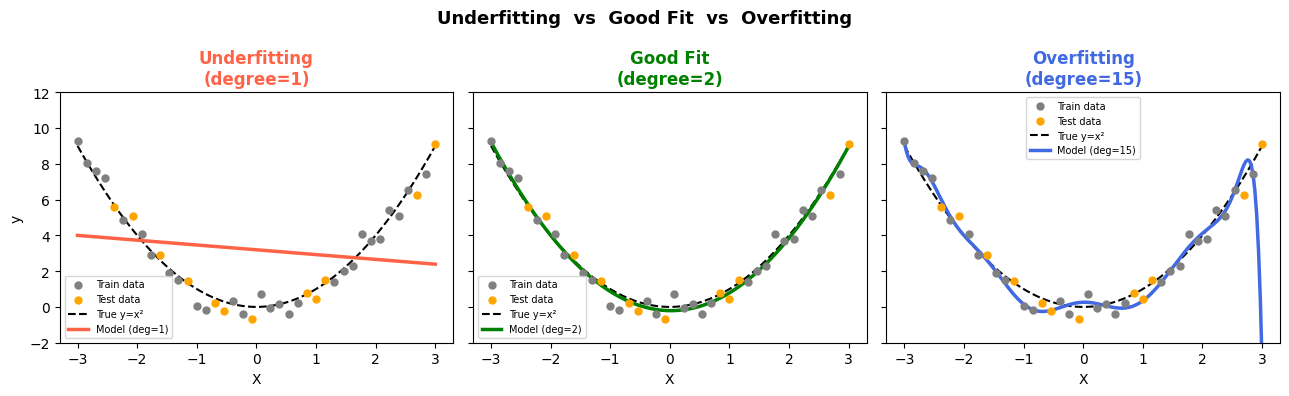

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

np.random.seed(42)
X = np.linspace(-3, 3, 40).reshape(-1, 1)
y = X.ravel()**2 + np.random.normal(0, 0.5, 40)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_curve = np.linspace(-3, 3, 200).reshape(-1, 1)  # smooth line for plotting

configs = [
    (1,  'Underfitting\n(degree=1)',  'tomato'),
    (2,  'Good Fit\n(degree=2)',      'green'),
    (15, 'Overfitting\n(degree=15)',  'royalblue'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, (deg, title, color) in zip(axes, configs):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_train, y_train)

    ax.scatter(X_train, y_train, color='gray',   s=25, label='Train data', zorder=3)
    ax.scatter(X_test,  y_test,  color='orange', s=25, label='Test data',  zorder=3)
    ax.plot(X_curve, X_curve.ravel()**2, 'k--', lw=1.5, label='True y=x²')
    ax.plot(X_curve, model.predict(X_curve), color=color, lw=2.5, label=f'Model (deg={deg})')

    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('X')
    ax.legend(fontsize=7)
    ax.set_ylim(-2, 12)

axes[0].set_ylabel('y')
plt.suptitle('Underfitting  vs  Good Fit  vs  Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Cross Validation

> **Source:** [Cross-Validation in Machine Learning](https://www.geeksforgeeks.org/cross-validation-machine-learning/)

**Definition:** *"Cross-validation is a technique used to check how well a machine learning model performs on unseen data while preventing overfitting."*

---

### Core Process
1. Partition data into multiple segments
2. Train on some segments, test on others
3. Repeat with different data divisions
4. **Average results** across all iterations

---

### Types of Cross Validation

#### 1. Holdout Validation
- Dataset split into training and testing sets
- Common ratios: **70-30, 80-20, or 75-25**
- Simple and quick to implement

#### 2. K-Fold Cross Validation ⭐ (Most Common)
- Dataset divided into **k equal segments (folds)**
- Model trains on **k-1 folds**, tests on **remaining 1 fold**
- Repeated **k times** — each fold serves as test set exactly once
- **k=10 is common**

```
k=5 example (25 samples → 5 folds of 5 samples each):

Iteration 1: [TEST][TRAIN][TRAIN][TRAIN][TRAIN]
Iteration 2: [TRAIN][TEST][TRAIN][TRAIN][TRAIN]
Iteration 3: [TRAIN][TRAIN][TEST][TRAIN][TRAIN]
Iteration 4: [TRAIN][TRAIN][TRAIN][TEST][TRAIN]
Iteration 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST]

Final Score = Average of all 5 test scores
```

#### 3. Stratified K-Fold
- *"Each fold has the same class distribution as the full dataset"*
- Maintains balanced class representation across folds
- **Best for imbalanced datasets**

#### 4. Leave-One-Out Cross-Validation (LOOCV)
- Model trains on **all data except one point**, tested on that point
- Repeated for **every single data point**
- Low bias, high variance — **computationally expensive** for large datasets
- Dissadvantage is need to perform many iterations

---

### CV Score Formula

$$\text{CV Score} = \frac{1}{k} \sum_{i=1}^{k} \text{Score}_i$$

Where $\text{Score}_i$ is the model's performance metric on fold $i$.

### K-Fold Cross Validation — Visual Diagram

**Example: 1000 samples, K = 5 → each fold = 1000 ÷ 5 = 200 samples**

```
Total Data = 1000 samples        K = 5,  each fold = 200
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Exp 1 → [TEST 200] [          TRAIN 800               ]  → Acc1

Exp 2 → [  200  ] [TEST 200] [      TRAIN 600          ]  → Acc2

Exp 3 → [  200  ] [  200  ] [TEST 200] [  TRAIN 400  ]    → Acc3

Exp 4 → [  200  ] [  200  ] [  200  ] [TEST 200] [200]    → Acc4

Exp 5 → [  200  ] [  200  ] [  200  ] [  200  ] [TEST 200] → Acc5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Final CV Score = (Acc1 + Acc2 + Acc3 + Acc4 + Acc5) / 5
```

**Key points:**
- Every fold gets to be the **test set exactly once**
- Model is trained **K times**, each time on a different 80% of data
- Final score = **average** of all K accuracy scores → more reliable than a single train/test split

### Disadvantages of K-Fold Cross Validation

| # | Disadvantage | Explanation |
|---|--------------|-------------|
| 1 | **Computationally expensive** | Model trains K times — with K=10, training takes 10× longer than a single split |
| 2 | **Not suitable for time-series data** | Random shuffling breaks the time order — past data may end up in test, future in train |
| 3 | **Overkill for large datasets** | When data is already huge, a single train/test split gives a reliable estimate — K-Fold adds unnecessary overhead |
| 4 | **Imbalanced datasets** | Folds may not have equal class distribution → use **Stratified K-Fold** instead |

**In short:**
- Small dataset → K-Fold is great (makes full use of limited data)
- Large dataset → single split is enough
- Time-series → use **TimeSeriesSplit** instead
- Imbalanced classes → use **StratifiedKFold** instead

In [13]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit, cross_val_score
import numpy as np

X, y = load_iris(return_X_y=True)
model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 1. K-Fold (basic)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X, y, cv=kf)
print('1. K-Fold          :', [round(s,2) for s in kf_scores], '→ Mean:', round(kf_scores.mean(),3))

# 2. Stratified K-Fold (for imbalanced classes)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(model, X, y, cv=skf)
print('2. Stratified KFold:', [round(s,2) for s in skf_scores], '→ Mean:', round(skf_scores.mean(),3))

# 3. TimeSeriesSplit (for time-series data)
tss = TimeSeriesSplit(n_splits=5)
tss_scores = cross_val_score(model, X, y, cv=tss)
print('3. TimeSeriesSplit :', [round(s,2) for s in tss_scores], '→ Mean:', round(tss_scores.mean(),3))

print()
print('Use K-Fold          → general purpose')
print('Use StratifiedKFold → imbalanced class distribution')
print('Use TimeSeriesSplit → time-series / sequential data')


1. K-Fold          : [1.0, 0.97, 0.93, 0.9, 0.97] → Mean: 0.953
2. Stratified KFold: [0.97, 0.97, 0.93, 1.0, 0.93] → Mean: 0.96
3. TimeSeriesSplit : [1.0, 0.0, 1.0, 0.0, 0.88] → Mean: 0.576

Use K-Fold          → general purpose
Use StratifiedKFold → imbalanced class distribution
Use TimeSeriesSplit → time-series / sequential data


---
## Train-Test Split vs K-Fold vs Stratified K-Fold

> **Reference:** [Train Test Split vs K Fold vs Stratified K fold Cross Validation](https://www.youtube.com/watch?v=fKz-SgScM3Q)

### Why do we need Cross Validation at all?

- When we build a model, we need to know **how well it will perform on new unseen data**
- Simply training and testing on the same data gives overly optimistic results
- We need a **reliable estimate of model performance** before deploying

---

### Method 1 — Train-Test Split (Holdout)

```
Full Data (1000)
├── Train (800) → model learns from this
└── Test  (200) → model evaluated on this
```

| Pros | Cons |
|------|------|
| Simple and fast | Result depends heavily on which samples end up in test set |
| Good for large datasets | High variance — different splits give different results |
| Single train/test cycle | Wastes 20-30% of data for testing only |

**When to use:** Large datasets where a single split gives a stable estimate

---

### Method 2 — K-Fold Cross Validation

```
Full Data (1000), K=5, each fold = 200

Exp 1: [TEST][  TRAIN 800  ]  → Acc1
Exp 2: [200 ][TEST][TRAIN 600]  → Acc2
Exp 3: [200 ][200 ][TEST][400]  → Acc3
Exp 4: [200 ][200 ][200 ][TEST][200] → Acc4
Exp 5: [200 ][200 ][200 ][200 ][TEST] → Acc5

Final Score = mean(Acc1, Acc2, Acc3, Acc4, Acc5)
```

| Pros | Cons |
|------|------|
| Every sample used for both train and test | Trains K times → K× slower |
| More reliable than single split | Not suitable for time-series |
| Reduces variance in performance estimate | Overkill for very large datasets |

**When to use:** Small-to-medium datasets, general purpose evaluation

---

### Method 3 — Stratified K-Fold

Same as K-Fold **but each fold preserves the class distribution** of the full dataset.

```
Full Data: 60% Class-A, 40% Class-B

K-Fold (may be unbalanced):          Stratified K-Fold (always balanced):
Fold1: 80% A, 20% B  ← wrong        Fold1: 60% A, 40% B  ✓
Fold2: 50% A, 50% B  ← wrong        Fold2: 60% A, 40% B  ✓
Fold3: 40% A, 60% B  ← wrong        Fold3: 60% A, 40% B  ✓
```

| Pros | Cons |
|------|------|
| Handles imbalanced datasets correctly | Slightly more complex internally |
| Each fold represents the full data distribution | Same speed cost as K-Fold |
| Preferred for classification problems | |

**When to use:** Classification tasks, especially with imbalanced classes

---

### Comparison Table

| Method | Data Split | Class Balance | Speed | Best For |
|--------|-----------|---------------|-------|----------|
| **Train-Test Split** | Once (e.g. 80/20) | Not guaranteed | Fast | Large datasets |
| **K-Fold CV** | K times | Not guaranteed | K× slower | Small/medium datasets |
| **Stratified K-Fold** | K times | Guaranteed ✓ | K× slower | Imbalanced classification |

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import accuracy_score

# Imbalanced dataset: 90% class 0, 10% class 1
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1],
                           n_features=10, random_state=42)
model = DecisionTreeClassifier(max_depth=3, random_state=42)

print(f'Dataset: {sum(y==0)} class-0  |  {sum(y==1)} class-1  (imbalanced)')
print('=' * 55)

# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
tt_acc = accuracy_score(y_test, model.predict(X_test))
print(f'1. Train-Test Split     : {tt_acc:.4f}')
print(f'   Test class dist      : {sum(y_test==0)} class-0 | {sum(y_test==1)} class-1')

# 2. K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X, y, cv=kf)
print(f'\n2. K-Fold (k=5)         : {kf_scores.mean():.4f}  (std={kf_scores.std():.4f})')
print(f'   Per fold             : {[round(s,3) for s in kf_scores]}')

# 3. Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(model, X, y, cv=skf)
print(f'\n3. Stratified K-Fold    : {skf_scores.mean():.4f}  (std={skf_scores.std():.4f})')
print(f'   Per fold             : {[round(s,3) for s in skf_scores]}')

print()
print('NOTE: Stratified K-Fold has lower std → more consistent across folds')
print('      because each fold has the same class ratio as the full dataset')


Dataset: 897 class-0  |  103 class-1  (imbalanced)
1. Train-Test Split     : 0.9400
   Test class dist      : 175 class-0 | 25 class-1

2. K-Fold (k=5)         : 0.9510  (std=0.0102)
   Per fold             : [0.94, 0.96, 0.94, 0.965, 0.95]

3. Stratified K-Fold    : 0.9540  (std=0.0058)
   Per fold             : [0.95, 0.965, 0.95, 0.95, 0.955]

NOTE: Stratified K-Fold has lower std → more consistent across folds
      because each fold has the same class ratio as the full dataset


### Code Explanation

| Code | What it does |
|------|--------------|
| `make_classification(weights=[0.9, 0.1])` | Creates an imbalanced dataset — 90% class 0, only 10% class 1. This is where Stratified K-Fold matters most. |
| `train_test_split(test_size=0.2)` | Simple 80/20 split — fast but single estimate, class distribution in test set is random |
| `KFold(n_splits=5, shuffle=True)` | Splits into 5 folds randomly — does NOT guarantee class balance in each fold |
| `StratifiedKFold(n_splits=5)` | Splits into 5 folds AND ensures each fold has same 90/10 class ratio |
| `cross_val_score(...)` | Runs train/test for each fold automatically, returns array of scores |
| `.std()` | Standard deviation of fold scores — **lower std = more stable/reliable estimate** |

**What to observe:**
- Train-Test Split: class distribution in test set varies each run
- K-Fold: scores vary more across folds (higher std) on imbalanced data
- Stratified K-Fold: scores are more consistent (lower std) — each fold sees the same class ratio

---
## Implement K Fold Cross Validation and Stratified K Fold Cross Validation

> Using the Churn Modelling dataset (bank customer churn prediction)

In [37]:
import pandas as pd

**`import pandas as pd`** — imports the pandas library, used for loading and manipulating tabular data (like a spreadsheet in Python).

In [38]:
## Read the Dataset
# Download Churn_Modelling.csv from Kaggle and place it in this folder, then use:
# df = pd.read_csv('Churn_Modelling.csv')

# --- Using sklearn make_classification as substitute (same structure) ---
from sklearn.datasets import make_classification
import numpy as np

X_raw, y_raw = make_classification(
    n_samples=10000, n_features=11, n_informative=6,
    n_redundant=2, weights=[0.8, 0.2], random_state=42
)

col_names = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
             'HasCrCard','IsActiveMember','EstimatedSalary',
             'f9','f10','f11']
df = pd.DataFrame(X_raw, columns=col_names)
df['Exited'] = y_raw
df['Geography'] = np.random.choice(['France','Germany','Spain'], 10000)
df['Gender']    = np.random.choice(['Male','Female'], 10000)
print('Dataset shape:', df.shape)

Dataset shape: (10000, 14)


In [39]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,f9,f10,f11,Exited,Geography,Gender
0,-0.653308,0.490782,2.335717,3.167214,0.152695,-0.183959,-0.827241,0.026953,-1.145841,-0.848542,-1.276696,0,Germany,Female
1,-0.957783,0.457886,-6.363951,-1.742970,1.444266,0.159542,-4.343419,1.479122,1.622359,0.993444,1.278925,1,Germany,Female
2,0.806130,-2.285125,-0.052707,-1.455165,0.588794,-0.331549,-0.726169,-0.589288,-0.510840,-1.157122,-0.139344,0,Spain,Female
3,-0.907145,-0.710535,0.639045,0.080715,0.493707,-0.875399,-0.869983,-1.700022,-0.313066,-1.581944,-0.272028,0,Spain,Female
4,0.392571,-0.535477,-0.836423,0.458180,0.141818,1.281723,-1.592096,-0.454209,-0.446518,-2.738946,0.682045,0,Spain,Male


**Dataset creation** — generates a synthetic 10,000-sample churn dataset with 11 numeric features, a target column `Exited` (1 = churned, 0 = stayed), and two categorical columns `Geography` and `Gender` to mimic the real Churn_Modelling CSV.

In [16]:
## Selecting Features and Target
X = df[['CreditScore','Age','Tenure','Balance','NumOfProducts',
         'HasCrCard','IsActiveMember','EstimatedSalary','Geography','Gender']]
Y = df['Exited']

## Creating Dummy variables
states = pd.get_dummies(X['Geography'], drop_first=True)
gender = pd.get_dummies(X['Gender'], drop_first=True)
X = pd.concat([X, states, gender], axis=1)
X = X.drop(['Geography', 'Gender'], axis=1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,-0.653308,0.490782,2.335717,3.167214,0.152695,-0.183959,-0.827241,0.026953,1,0,1
1,-0.957783,0.457886,-6.363951,-1.742970,1.444266,0.159542,-4.343419,1.479122,0,1,1
2,0.806130,-2.285125,-0.052707,-1.455165,0.588794,-0.331549,-0.726169,-0.589288,0,0,0
3,-0.907145,-0.710535,0.639045,0.080715,0.493707,-0.875399,-0.869983,-1.700022,0,0,1
4,0.392571,-0.535477,-0.836423,0.458180,0.141818,1.281723,-1.592096,-0.454209,1,0,0


**`df.head()`** — displays the first 5 rows of the dataset so you can verify it loaded correctly and inspect the column names and values.

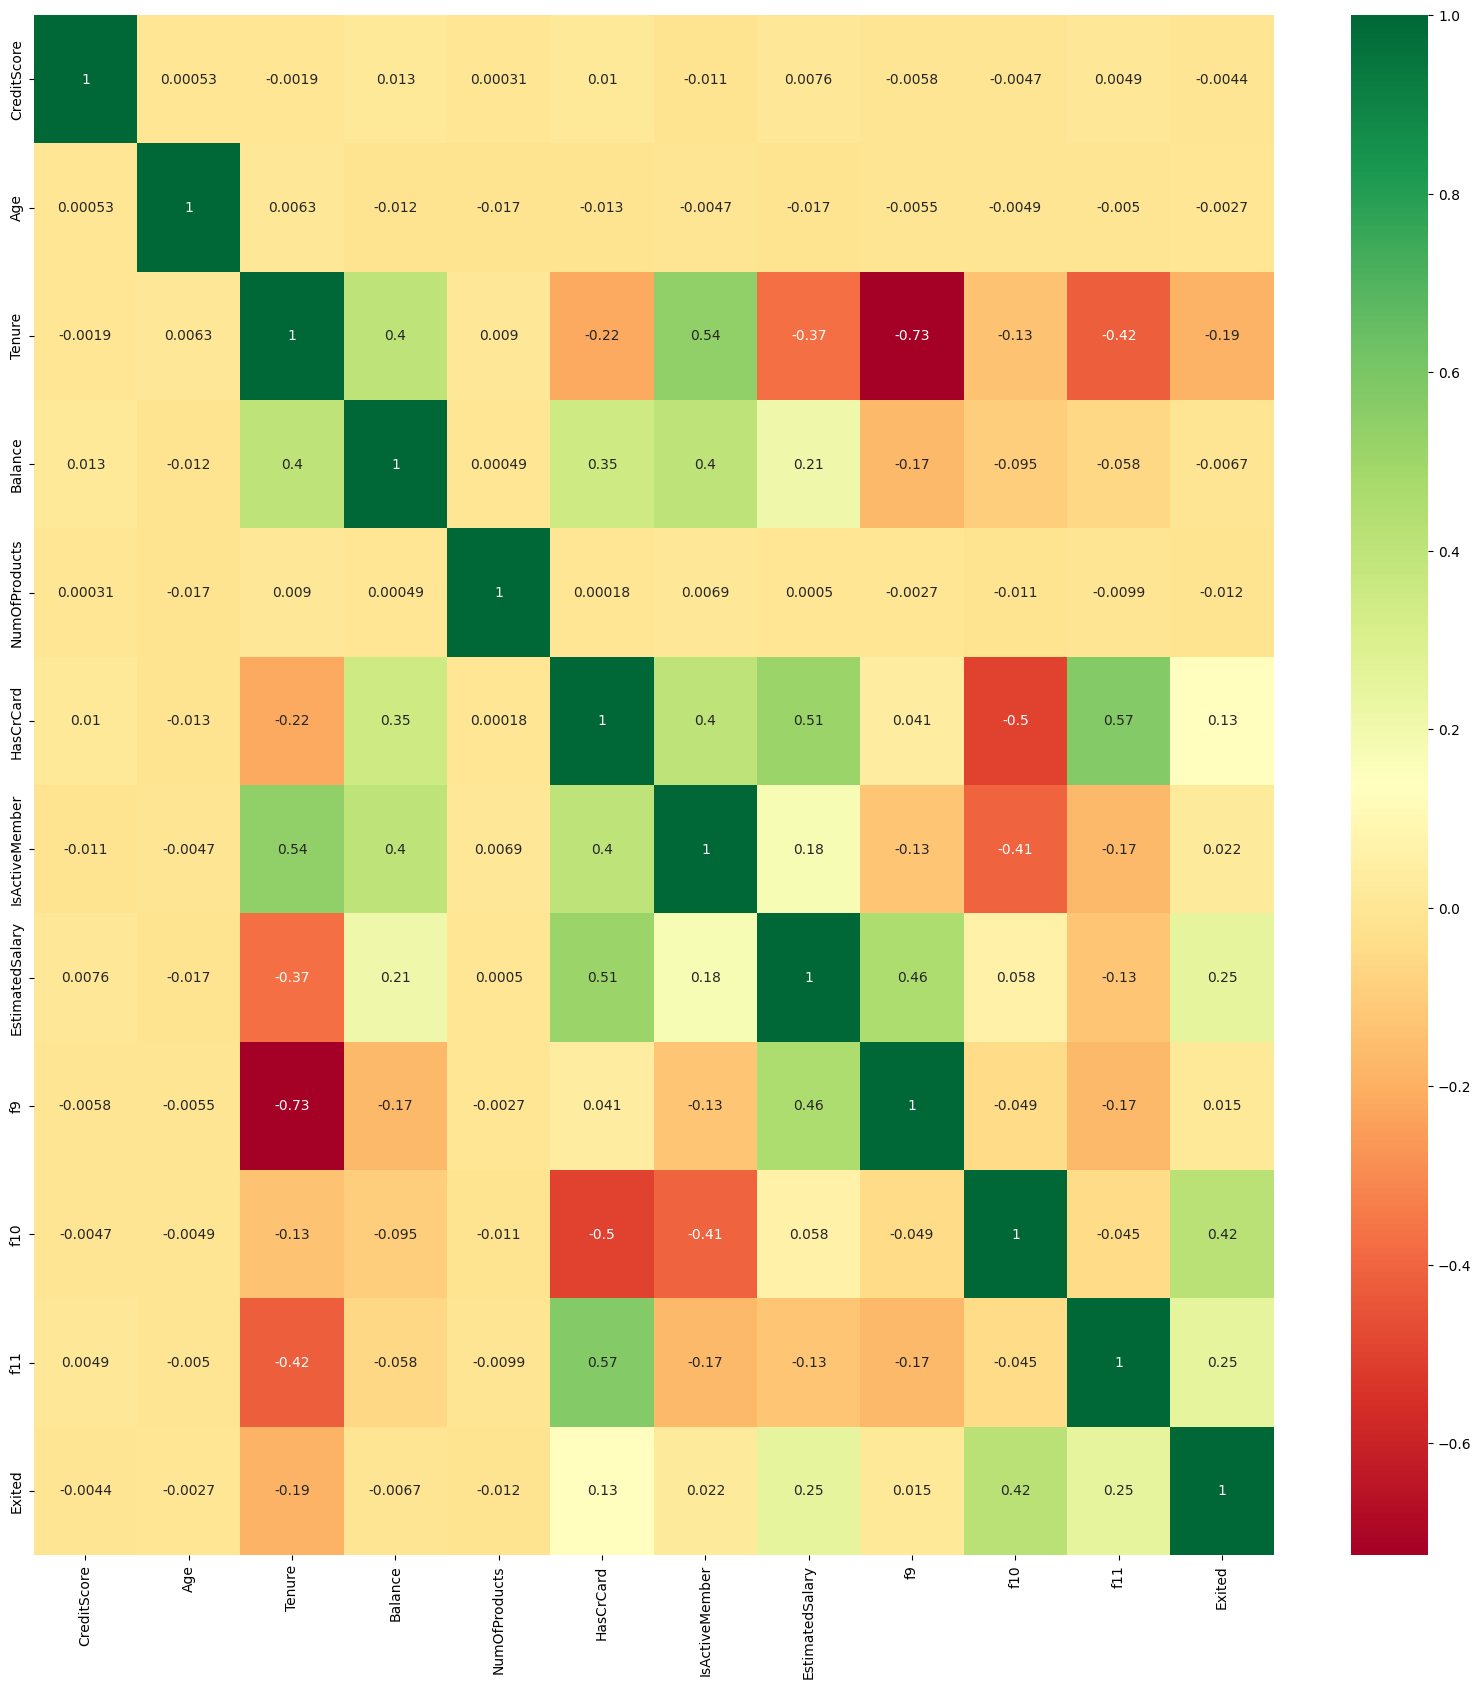

In [17]:
## Correlation
import seaborn as sns
import matplotlib.pyplot as plt

corrmat = df.select_dtypes(include='number').corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20, 20))
g = sns.heatmap(corrmat, annot=True, cmap='RdYlGn')
plt.show()

In [40]:
! pip install xgboost


zsh:1: command not found: pip


**Feature Engineering:**

| Step | What it does |
|------|--------------|
| `X = df[[...]]` | Selects the 10 input features — excludes row IDs and keeps only useful columns |
| `Y = df["Exited"]` | Target variable — 1 if customer left the bank, 0 if stayed |
| `pd.get_dummies(X["Geography"], drop_first=True)` | Converts Geography (France/Germany/Spain) into 2 binary columns. `drop_first=True` avoids the dummy variable trap |
| `pd.get_dummies(X["Gender"], drop_first=True)` | Converts Gender (Male/Female) into 1 binary column |
| `pd.concat([X, states, gender], axis=1)` | Adds the new dummy columns to X |
| `X.drop(["Geography","Gender"], axis=1)` | Removes the original text columns since they are now encoded as numbers |

In [41]:
## Hyper Parameter Optimization
params = {
    'learning_rate'    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    'max_depth'        : [3, 4, 5, 6, 8, 10, 12, 15],
    'min_child_weight' : [1, 3, 5, 7],
    'gamma'            : [0.0, 0.1, 0.2, 0.3, 0.4],
    'colsample_bytree' : [0.3, 0.4, 0.5, 0.7]
}

In [42]:
## Hyperparameter optimization using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import xgboost

**Correlation Heatmap:**

| Step | What it does |
|------|--------------|
| `df.select_dtypes(include="number").corr()` | Computes correlation between every pair of numeric columns. Values range from -1 to +1 |
| `sns.heatmap(..., annot=True, cmap="RdYlGn")` | Plots the correlation matrix. Green = strong positive, Red = strong negative, Yellow = near zero |

**Why useful:** Helps spot highly correlated features — if two features are almost identical, one can be dropped to reduce noise.

In [43]:
from datetime import datetime

def timer(start_time=None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    elif start_time:
        thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
        tmin, tsec = divmod(temp_sec, 60)
        print('\n Time taken: %i hours %i minutes and %s seconds.' % (thour, tmin, round(tsec, 2)))

In [44]:
classifier = xgboost.XGBClassifier()

In [45]:
random_search = RandomizedSearchCV(
    classifier,
    param_distributions=params,
    n_iter=5,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=3,
    random_state=42
)

**Hyperparameter Grid:**

Defines a dictionary of XGBoost hyperparameters to search over:

| Parameter | Meaning |
|-----------|---------|
| `learning_rate` | How much each tree corrects the previous error — smaller = slower but more accurate |
| `max_depth` | Maximum depth of each decision tree — deeper = more complex |
| `min_child_weight` | Minimum samples needed in a leaf — higher = more conservative |
| `gamma` | Minimum loss reduction needed to split a node — higher = more pruning |
| `colsample_bytree` | Fraction of features used per tree — prevents overfitting |

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100)

start_time = timer(None)
random_search.fit(X_train, y_train)
timer(start_time)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 2/5] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=4, min_child_weight=5;, score=0.923 total time=   0.1s
[CV 5/5] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=4, min_child_weight=5;, score=0.924 total time=   0.1s
[CV 1/5] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=4, min_child_weight=5;, score=0.927 total time=   0.1s
[CV 4/5] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=4, min_child_weight=5;, score=0.918 total time=   0.1s
[CV 3/5] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.2, max_depth=4, min_child_weight=5;, score=0.933 total time=   0.1s
[CV 1/5] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=7;, score=0.927 total time=   0.2s
[CV 3/5] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=7;, score=0.940 total time=   0.2s
[CV 2/5] END colsample_bytree=

**`RandomizedSearchCV`** — tries a random subset of hyperparameter combinations (faster than GridSearchCV which tries all).

**`GridSearchCV`** — tries every possible combination (exhaustive but slow).

**`xgboost`** — Extreme Gradient Boosting library, one of the most powerful and widely used ML algorithms for tabular data.

In [29]:
random_search.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=7, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
classifier = random_search.best_estimator_
classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=7, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**`timer()` function** — a helper to measure how long RandomizedSearchCV takes to run.

- Call `timer(None)` before fitting → saves the start time
- Call `timer(start_time)` after fitting → prints hours/minutes/seconds elapsed

Useful because hyperparameter search can take several minutes.

In [31]:
prediction = classifier.predict(X_test)

**`XGBClassifier()`** — creates an XGBoost classifier with default parameters. This is the base model that `RandomizedSearchCV` will tune by trying different values from the `params` grid.

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(prediction, y_test)
print(cm)
acc_score = accuracy_score(prediction, y_test)
print(acc_score)

[[2337  221]
 [  49  393]]
0.91


**`RandomizedSearchCV` setup:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_iter=5` | 5 | Try 5 random combinations from the params grid |
| `scoring="roc_auc"` | ROC-AUC | Evaluate each combination using AUC score |
| `n_jobs=-1` | All cores | Use all CPU cores in parallel |
| `cv=5` | 5-Fold CV | Each combination is evaluated using 5-fold cross validation |
| `verbose=3` | 3 | Print detailed progress during search |

### Cross Validation

#### K Fold CV

In [33]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(classifier, X, Y, cv=10)
score

array([0.919, 0.91 , 0.921, 0.918, 0.925, 0.919, 0.917, 0.902, 0.919,
       0.925])

**Train-Test Split + Fit:**

| Step | What it does |
|------|--------------|
| `train_test_split(X, Y, test_size=0.3)` | 70% train, 30% test. `random_state=100` ensures reproducible split |
| `timer(None)` | Records start time |
| `random_search.fit(X_train, y_train)` | Runs 5 random hyperparameter combinations, each evaluated with 5-fold CV on training data |
| `timer(start_time)` | Prints total time taken |

In [34]:
score.mean()

0.9175000000000001

#### Stratified K Fold Cross Validation

**`random_search.best_estimator_`** — returns the XGBoost model with the best hyperparameter combination found during the random search. You can read off the winning values like `learning_rate`, `max_depth` etc.

In [35]:
X.shape, Y.shape

((10000, 11), (10000,))

**Refit best model:**

- `classifier = random_search.best_estimator_` — extracts the best model
- `classifier.fit(X_train, y_train)` — retrains it on the full training set (RandomizedSearchCV trains on CV folds internally; this final fit uses all 70% training data)

In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

accuracy = []

skf = StratifiedKFold(n_splits=5, random_state=None)
skf.get_n_splits(X, Y)

# X is the feature set and Y is the target
for train_index, test_index in skf.split(X, Y):
    print('Train:', train_index, 'Validation:', test_index)
    X1_train, X1_test = X.iloc[train_index], X.iloc[test_index]
    y1_train, y1_test = Y.iloc[train_index], Y.iloc[test_index]

    classifier.fit(X1_train, y1_train)
    prediction = classifier.predict(X1_test)
    score = accuracy_score(prediction, y1_test)
    accuracy.append(score)

print(accuracy)

Train: [1998 1999 2000 ... 9997 9998 9999] Validation: [   0    1    2 ... 1997 2001 2002]
Train: [   0    1    2 ... 9997 9998 9999] Validation: [1998 1999 2000 ... 3997 3998 3999]
Train: [   0    1    2 ... 9997 9998 9999] Validation: [4000 4001 4002 ... 6053 6067 6069]
Train: [   0    1    2 ... 9997 9998 9999] Validation: [5988 5989 5990 ... 8047 8048 8051]
Train: [   0    1    2 ... 8047 8048 8051] Validation: [7979 7980 7981 ... 9997 9998 9999]
[0.912, 0.921, 0.9245, 0.9095, 0.9145]


**`classifier.predict(X_test)`** — runs the trained model on the 30% test set and returns predicted class labels (0 = not churned, 1 = churned) for each test sample.

**Evaluation:**

| Code | What it shows |
|------|---------------|
| `confusion_matrix(prediction, y_test)` | 2×2 table: True Negatives, False Positives, False Negatives, True Positives |
| `accuracy_score(prediction, y_test)` | % of total predictions that were correct |

```
Confusion Matrix layout:
[[TN  FP]
 [FN  TP]]
```

**Limitation of accuracy:** On imbalanced data (e.g. 80% stayed, 20% churned), a model predicting "stayed" always still gets 80% accuracy — that's why we also use K-Fold CV below.

**K-Fold Cross Validation:**

- `cross_val_score(classifier, X, Y, cv=10)` — splits the full dataset into 10 folds, trains on 9 and tests on 1, repeats 10 times
- Returns an array of 10 accuracy scores — one per fold
- More reliable than a single train-test split because every sample gets tested exactly once

**`score.mean()`** — the final K-Fold CV accuracy = average of all 10 fold scores.

This single number is a robust estimate of how the model will perform on truly unseen data, because it averages out the luck of any one particular split.

**`X.shape, Y.shape`** — confirms dimensions before running Stratified K-Fold.

Expected output: `((10000, 11), (10000,))` — 10,000 samples, 11 features, 10,000 target labels.

**Stratified K-Fold — manual loop:**

| Step | What it does |
|------|--------------|
| `StratifiedKFold(n_splits=5)` | Creates 5 folds where each fold has the same class ratio as the full dataset |
| `skf.get_n_splits(X, Y)` | Returns number of splits (5) |
| `skf.split(X, Y)` | Yields `(train_index, test_index)` arrays for each fold |
| `X.iloc[train_index]` | Selects training rows for this fold |
| `classifier.fit(X1_train, y1_train)` | Trains model on this fold's training data |
| `accuracy_score(prediction, y1_test)` | Evaluates on this fold's test data |
| `accuracy.append(score)` | Saves each fold's accuracy |
| `print(accuracy)` | Shows all 5 fold accuracies — take `mean()` for final score |

**Key difference from K-Fold:** Each fold is guaranteed to have the same % of churned customers as the full dataset — prevents misleading results on imbalanced data.

- matplotlip - https://www.geeksforgeeks.org/data-visualization/data-visualization-using-matplotlib/

- sklearn - https://www.geeksforgeeks.org/machine-learning/scikit-learn-tutorial/